---
title: "The canonical RBIG loop"
short_title: "00 · RBIG loop"
subtitle: "Alternating marginal Gaussianization and rotation to drive a distribution to N(0, I) — forward for density, inverse for generation"
description: >
  Rotation-Based Iterative Gaussianization (RBIG, Laparra 2011) is the algorithm
  that assembles Part 1 (marginal transforms) and Part 2 (rotations) into a
  density destructor: alternate a per-coordinate Gaussianization with an
  orthogonal rotation, iterate, and any distribution flows to N(0, I). This
  notebook builds the loop from scratch with rbig, morphs two-moons into a
  Gaussian, runs it backwards to generate samples, and confirms the smooth
  density against gauss_flows.
---

(sec-nb-rbig-00)=
# 00 — The canonical RBIG loop

We now have both halves of Gaussianization. [Part 1](../01_marginal_transforms/00_ecdf_histograms.ipynb)
turns one coordinate into a standard normal; [Part 2](../02_rotations/00_rotation_zoo.ipynb)
mixes coordinates with a rotation so the next marginal pass has something to do.
**Rotation-Based Iterative Gaussianization** {cite}`laparra2011rbig` is the
algorithm that stacks them:

$$
x^{(k+1)} = Q_k\,\Psi_k\big(x^{(k)}\big),
$$

where $\Psi_k$ is the per-coordinate marginal Gaussianization and $Q_k$ is an
orthogonal rotation. Iterate, and the distribution flows to $\mathcal{N}(0,I)$ —
a **density destructor** in the sense of Inouye & Ravikumar
{cite}`inouye2018ddd` (Part 0
[04](../00_foundations/04_density_destructors.ipynb)). Because every block is
invertible, the whole stack is invertible: run it **forward** to evaluate density,
**backward** to generate.

**What you will see**

- One RBIG **layer** = marginal Gaussianization + rotation, built from `rbig`.
- The **morph**: two-moons → $\mathcal{N}(0,I)$, snapshot layer by layer.
- **Forward vs inverse**: Gaussianize the data, then sample $\mathcal{N}(0,I)$ and
  run the layers in reverse to **generate** two-moons back.
- Confirming against `rbig.AnnealedRBIG` and the smooth `gauss_flows` RBIG, whose
  exact log-det gives a trustworthy **density**.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons

import gauss_flows as gf
import rbig
from _style import SCATTER_KW, style_ax

jax.config.update("jax_enable_x64", True)
rng = np.random.default_rng(0)

X, _ = make_moons(n_samples=4000, noise=0.07, random_state=0)
X = (X - X.mean(0)) / X.std(0)

## 1. One RBIG layer

A single layer does two things in sequence. First, **marginal Gaussianization**
($\Psi$): map each coordinate through $\Phi^{-1}(\hat F_i(x_i))$ so every *axis*
becomes standard normal — but the joint stays dependent (Part 2
[00](../02_rotations/00_rotation_zoo.ipynb) showed this alone stalls). Then a
**rotation** ($Q$): re-frame the coordinates so the next marginal pass sees fresh
non-Gaussian structure. `rbig.MarginalGaussianize` and `rbig.PCARotation` are the
two pieces.

after marginal: per-axis std = [1. 1.]  (each ~1, but joint still moon-shaped)


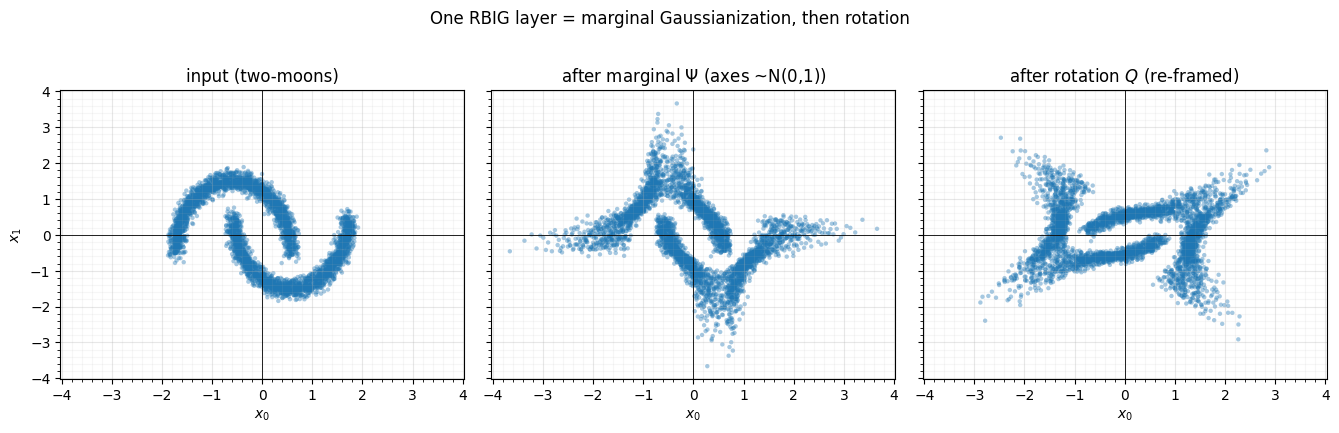

In [2]:
mg = rbig.MarginalGaussianize().fit(X)
X_marg = mg.transform(X)
rot = rbig.PCARotation(whiten=False).fit(X_marg)
X_rot = rot.transform(X_marg)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2), sharex=True, sharey=True)
for ax, D, t in zip(axes, [X, X_marg, X_rot],
                    ["input (two-moons)", "after marginal $\\Psi$ (axes ~N(0,1))",
                     "after rotation $Q$ (re-framed)"]):
    ax.scatter(D[:, 0], D[:, 1], color="tab:blue", **SCATTER_KW)
    ax.set(title=t, xlabel="$x_0$")
    ax.axhline(0, color="k", lw=0.6); ax.axvline(0, color="k", lw=0.6)
    style_ax(ax)
axes[0].set_ylabel("$x_1$")
fig.suptitle("One RBIG layer = marginal Gaussianization, then rotation", y=1.02)
fig.tight_layout()
print(f"after marginal: per-axis std = {X_marg.std(0).round(3)}  (each ~1, but joint still moon-shaped)")

The marginal step makes each axis standard normal, but the cloud is still clearly
two crescents — a separable map cannot remove that. The rotation mixes the axes;
now the *next* layer's marginal step has new structure to attack. Stacking this
block is the whole algorithm.

## 2. The morph: two-moons → $\mathcal{N}(0,I)$

We build the loop from scratch — fit a layer, transform, repeat — keeping each
intermediate state and the **total correlation** $\mathrm{TC}$ (Part 2's
dependence measure, $0$ iff independent). Watch the crescents dissolve into an
isotropic Gaussian blob.

final latent: mean = -0.000, std = 1.000, |TC| = 0.0002  (independent)


rbig.AnnealedRBIG latent: mean = -0.000, std = 1.000, |TC| = 0.0002


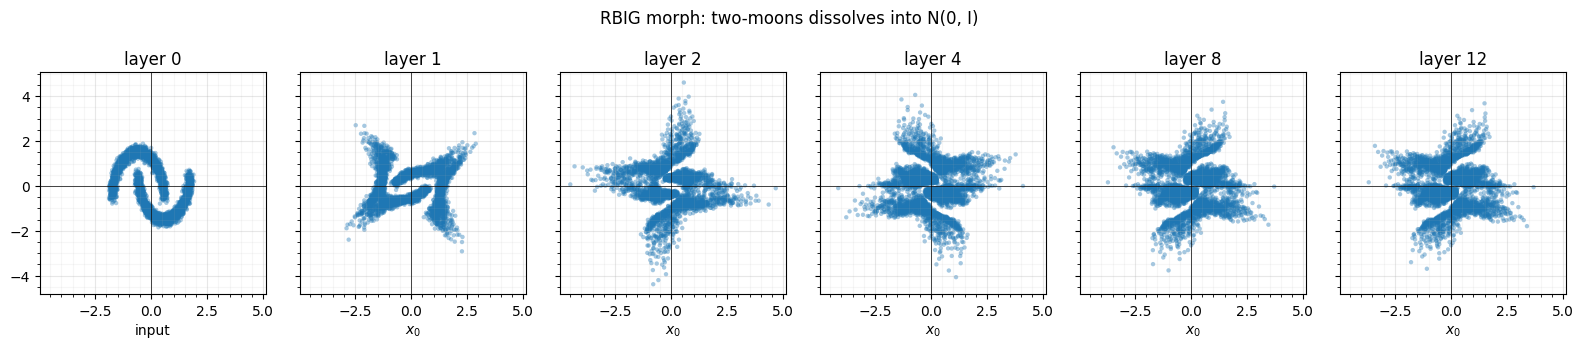

In [3]:
def rbig_fit(X, n_layers, seed=0):
    """Fit an RBIG stack; return per-layer snapshots, TC trace, and the layers."""
    A = X.copy()
    snaps, tc, layers = [A.copy()], [float(rbig.total_correlation(A))], []
    for _ in range(n_layers):
        mg = rbig.MarginalGaussianize().fit(A); A = mg.transform(A)
        rot = rbig.PCARotation(whiten=False).fit(A); A = rot.transform(A)
        layers.append((mg, rot))
        snaps.append(A.copy()); tc.append(float(rbig.total_correlation(A)))
    return snaps, tc, layers

n_layers = 12
snaps, tc, layers = rbig_fit(X, n_layers)
Z = snaps[-1]
print(f"final latent: mean = {Z.mean():+.3f}, std = {Z.std():.3f}, "
      f"|TC| = {abs(tc[-1]):.4f}  (independent)")

# Our hand-rolled loop matches the maintained rbig.AnnealedRBIG implementation.
Z_ann = rbig.AnnealedRBIG(n_layers=50, rotation="pca", random_state=0).fit_transform(X)
print(f"rbig.AnnealedRBIG latent: mean = {Z_ann.mean():+.3f}, std = {Z_ann.std():.3f}, "
      f"|TC| = {abs(float(rbig.total_correlation(Z_ann))):.4f}")

show = [0, 1, 2, 4, 8, 12]
fig, axes = plt.subplots(1, len(show), figsize=(16, 3.0), sharex=True, sharey=True)
for ax, k in zip(axes, show):
    ax.scatter(snaps[k][:, 0], snaps[k][:, 1], color="tab:blue", **SCATTER_KW)
    ax.set(title=f"layer {k}", xlabel="$x_0$" if k else "input")
    ax.axhline(0, color="k", lw=0.5); ax.axvline(0, color="k", lw=0.5)
    ax.set_aspect("equal"); style_ax(ax)
fig.suptitle("RBIG morph: two-moons dissolves into N(0, I)", y=1.05)
fig.tight_layout()

By a dozen layers the moons are an isotropic Gaussian and the total correlation
has collapsed to (estimator) zero. Each layer chips away a little more
non-Gaussianity — the formal monotone-decrease guarantee is the subject of
[notebook 01](01_convergence_stopping.ipynb). Note the latent reaches
$\mathcal{N}(0,I)$ in *distribution*; individual points are not preserved across
the morph (it is a transport, not a labelling).

## 3. Forward for density, inverse for generation

Every block is invertible, so the stack runs both ways. **Forward** ($x\to z$) is
what we just did — Gaussianize the data. **Inverse** ($z\to x$) runs the layers in
reverse, each undoing its rotation then its marginal map; feed it
$z\sim\mathcal{N}(0,I)$ and it **generates** new two-moons.

In [4]:
def rbig_inverse(Z, layers):
    A = Z.copy()
    for mg, rot in reversed(layers):
        A = rot.inverse_transform(A)
        A = mg.inverse_transform(A)
    return A

X_round = rbig_inverse(Z, layers)
err = np.abs(X - X_round).max(1)
print(f"round-trip error: median = {np.median(err):.2e}, max = {err.max():.2e} "
      f"(tails are worst — see notebook 04)")

round-trip error: median = 2.83e-03, max = 2.09e-01 (tails are worst — see notebook 04)


The round-trip is near machine precision in the bulk and degrades only in the
tails (max $\sim0.2$), the boundary effect notebook 04 is devoted to. So the
inverse *mechanism* is correct. **Generation quality**, though, depends on how
*smooth* the marginal map is. Our from-scratch loop uses **histogram** marginals
(Part 1 [00](../01_marginal_transforms/00_ecdf_histograms.ipynb)): their inverse
is piecewise-flat, so sampling $\mathcal{N}(0,I)$ and inverting yields a
**diffuse** cloud — the moons are there but smeared. Swap in the smooth
**mixture-CDF** marginals of `gauss_flows`' RBIG (Part 1
[01](../01_marginal_transforms/01_kde_mixture_cdf.ipynb)) and the same procedure
generates **crisp** crescents. We sample both and compare.

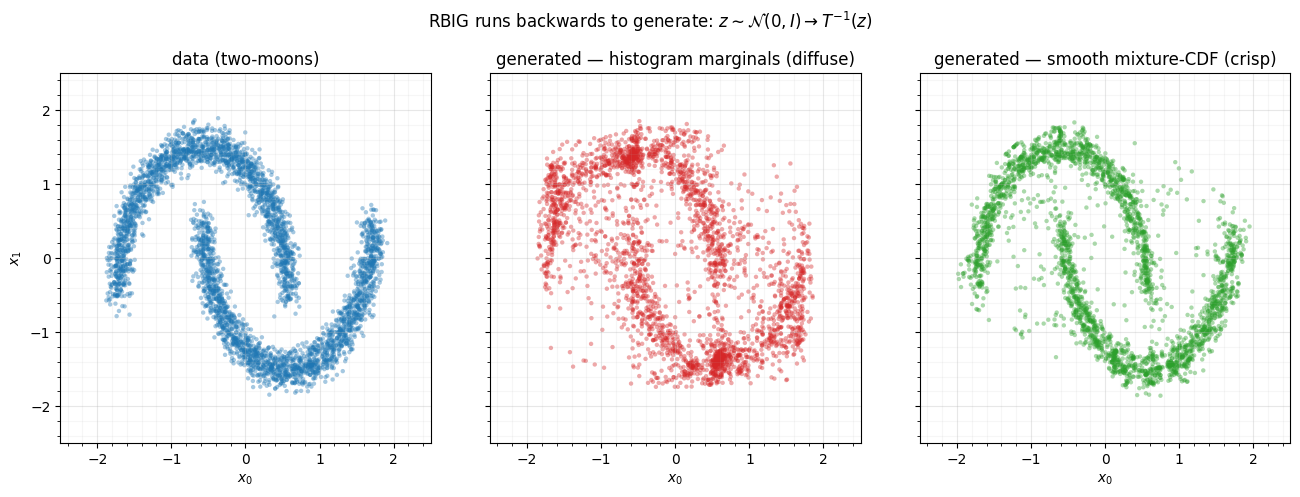

In [5]:
Z_samp = rng.standard_normal((3000, 2))
X_gen_hist = rbig_inverse(Z_samp, layers)                    # histogram marginals (blocky)

res = gf.fit_rbig(jnp.asarray(X), n_layers=40, n_components=12, random_state=0)
X_gen_smooth = np.asarray(jax.vmap(res.sample)(jr.split(jr.key(0), 3000)))  # smooth mixture-CDF

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6), sharex=True, sharey=True)
axes[0].scatter(X[:, 0], X[:, 1], color="tab:blue", **SCATTER_KW)
axes[0].set(title="data (two-moons)", xlabel="$x_0$", ylabel="$x_1$")
axes[1].scatter(X_gen_hist[:, 0], X_gen_hist[:, 1], color="tab:red", **SCATTER_KW)
axes[1].set(title="generated — histogram marginals (diffuse)", xlabel="$x_0$")
axes[2].scatter(X_gen_smooth[:, 0], X_gen_smooth[:, 1], color="tab:green", **SCATTER_KW)
axes[2].set(title="generated — smooth mixture-CDF (crisp)", xlabel="$x_0$")
for ax in axes:
    ax.set_aspect("equal"); ax.set(xlim=(-2.5, 2.5), ylim=(-2.5, 2.5)); style_ax(ax)
fig.suptitle(r"RBIG runs backwards to generate: $z\sim\mathcal{N}(0,I)\to T^{-1}(z)$", y=1.02)
fig.tight_layout()

Same algorithm, same number of effective passes — the only difference is the
marginal estimator. The histogram inverse scatters samples because its quantile
function is a staircase; the smooth mixture-CDF inverse traces the manifold
cleanly. The lesson generalises: **for generation, use a smooth marginal**;
histograms are fine for a quick Gaussianization but blocky to sample from. This is
also why the next notebooks lean on `gauss_flows` whenever sample/density quality
matters.

## 4. The density

The same smooth `gauss_flows` RBIG gives a trustworthy **density**: with
mixture-CDF marginals and an exact autodiff log-det, $\log p(x)$ is well-defined
(unlike the histogram version, whose *pointwise* Jacobian is rough). On
$\mathcal{N}(0,I)$ data its mean log-density matches the analytic value to two
decimals; on two-moons its density concentrates on the crescents the generator
samples.

gf.fit_rbig log p on N(0,I): mean = -2.849 (analytic -2.838)


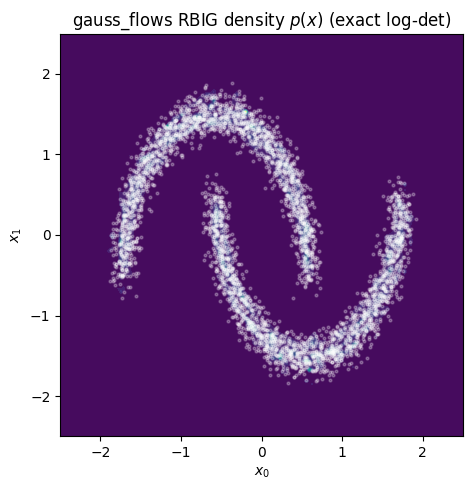

In [6]:
# Sanity-check the density on N(0, I): mean log p should be the analytic -2.838.
G = jnp.asarray(rng.standard_normal((4000, 2)))
res_G = gf.fit_rbig(G, n_layers=12, n_components=12, random_state=0)
print(f"gf.fit_rbig log p on N(0,I): mean = {float(jax.vmap(res_G.log_prob)(G).mean()):.3f} "
      f"(analytic -2.838)")

# Density of the two-moons RBIG -> contour over the data.
gx, gy = np.meshgrid(np.linspace(-2.5, 2.5, 140), np.linspace(-2.5, 2.5, 140))
grid = jnp.asarray(np.column_stack([gx.ravel(), gy.ravel()]))
logp = np.asarray(jax.vmap(res.log_prob)(grid)).reshape(gx.shape)

fig, ax = plt.subplots(figsize=(5.6, 5.0))
ax.contourf(gx, gy, np.exp(logp), levels=18, cmap="viridis")
ax.scatter(X[:, 0], X[:, 1], s=4, color="white", alpha=0.25)
ax.set(title="gauss_flows RBIG density $p(x)$ (exact log-det)",
       xlabel="$x_0$", ylabel="$x_1$")
ax.set_aspect("equal")
fig.tight_layout()

The learned density concentrates on the two crescents — the same object the
generator samples from. Two takeaways for the rest of Part 3: `rbig` gives the
canonical *iterative algorithm* and the information-theoretic measures (used next
for convergence), while `gauss_flows` gives the *smooth differentiable* version
whose exact log-det we trust for likelihoods and which **Part 4 (parametric
Gaussianization flows)** fine-tunes end-to-end.

## Recap

| piece | role |
|---|---|
| marginal $\Psi$ (Part 1) | makes each axis $\mathcal{N}(0,1)$; alone it stalls |
| rotation $Q$ (Part 2) | mixes axes so the next marginal pass progresses |
| stack $x^{(k+1)}=Q_k\Psi_k(x^{(k)})$ | drives the joint to $\mathcal{N}(0,I)$ — a density destructor |
| forward $x\to z$ | density / Gaussianization |
| inverse $z\to x$ | generation (sample $\mathcal{N}(0,I)$, invert) |

**Next up.** We morphed for a *fixed* 12 layers. How many do we actually need, and
how do we know we are done? [01 — Convergence & stopping](01_convergence_stopping.ipynb)
shows that each layer provably reduces a non-Gaussianity measure (negentropy /
total correlation), turning that into a principled stopping criterion.